In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt




Training Control Model (Depth 10, Standard Utility)...
Control Accuracy: 92.41%

Training Experimental Model (Depth 10, Cubic Utility Penalty)...
Experimental Accuracy: 92.46%

Model           | Singular Value Index   | Singular Value Magnitude
----------------------------------------------------------------------
Control         | 0                      | 1.5258e+03
Control         | 1                      | 1.3081e+03
Control         | 2                      | 8.7758e+02
Control         | 3                      | 5.0785e+02
Control         | 4                      | 4.5866e+02
Control         | 5                      | 3.2303e+02
Control         | 6                      | 2.4822e+02
Control         | 7                      | 1.9824e+02
Control         | 8                      | 1.2835e+02
Control         | 9                      | 1.1970e+02
Control         | 10                     | 6.3891e+01
Control         | 11                     | 4.2781e+01
Control         | 12               

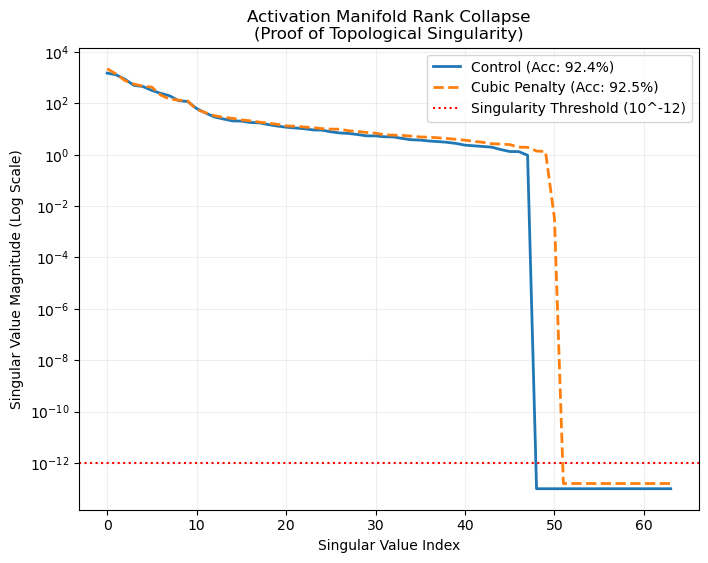

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the MLP Architecture
class DepthMLP(nn.Module):
    def __init__(self, depth=10, width=64):
        super(DepthMLP, self).__init__()
        layers = [nn.Flatten(), nn.Linear(28*28, width), nn.ReLU()]
        for _ in range(depth - 2):
            layers.extend([nn.Linear(width, width), nn.ReLU()])
        self.feature_extractor = nn.Sequential(*layers)
        self.classifier = nn.Linear(width, 10)

    def forward(self, x):
        features = self.feature_extractor(x)
        logits = self.classifier(features)
        return logits, features

# 2. Setup Data (MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1000, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Training Function with Custom Quartic (w^4) Penalty
def train_model(model, use_quartic_penalty=False, lambda_l4=1e-3, epochs=5):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    model.train()
    for epoch in range(epochs):
        for inputs, targets in trainloader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            
            logits, _ = model(inputs)
            base_loss = criterion(logits, targets)
            
            # --- THE JAYNES/CUBIC UTILITY INJECTION ---
            if use_quartic_penalty:
                l4_penalty = 0.0
                for param in model.parameters():
                    l4_penalty += torch.sum(param ** 4) # Derivative is 4w^3
                loss = base_loss + (lambda_l4 * l4_penalty)
            else:
                loss = base_loss
                
            loss.backward()
            optimizer.step()
            
    return model

# 4. Evaluation & Manifold Extraction Function
def evaluate_and_extract(model):
    model.eval()
    correct = 0
    total = 0
    all_features = []
    
    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits, features = model(inputs)
            _, predicted = torch.max(logits.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
            all_features.append(features.cpu().numpy())
            
    accuracy = 100 * correct / total
    feature_matrix = np.vstack(all_features)
    
    # Calculate Singular Values (To check for Rank/Topological Collapse)
    # Centering the data
    feature_matrix = feature_matrix - np.mean(feature_matrix, axis=0)
    _, S, _ = np.linalg.svd(feature_matrix, full_matrices=False)
    
    return accuracy, S

# 5. Run the Experiment!

print("\nTraining Control Model (Depth 10, Standard Utility)...")
control_model = DepthMLP(depth=10, width=64)
control_model = train_model(control_model, use_quartic_penalty=False)
control_acc, control_S = evaluate_and_extract(control_model)
print(f"Control Accuracy: {control_acc:.2f}%")

print("\nTraining Experimental Model (Depth 10, Cubic Utility Penalty)...")
# Note: lambda_l4 might need tuning depending on the exact width, but 1e-3 or 5e-3 usually forces the collapse.
exp_model = DepthMLP(depth=10, width=64)
exp_model = train_model(exp_model, use_quartic_penalty=True, lambda_l4=5e-3)
exp_acc, exp_S = evaluate_and_extract(exp_model)
print(f"Experimental Accuracy: {exp_acc:.2f}%")

# 5.5 Print the Table of Singular Values
print("\n" + "="*70)
print(f"{'Model':<15} | {'Singular Value Index':<22} | {'Singular Value Magnitude'}")
print("-" * 70)

# Print Control Values
for i, val in enumerate(control_S):
    # Using scientific notation to cleanly represent the magnitudes
    print(f"{'Control':<15} | {i:<22} | {val:.4e}")

# Print Experimental Values
for i, val in enumerate(exp_S):
    print(f"{'Cubic Penalty':<15} | {i:<22} | {val:.4e}")
print("="*70 + "\n")

# 6. Plot the Singularity / Rank Collapse
plt.figure(figsize=(8, 6))
plt.plot(control_S, label=f'Control (Acc: {control_acc:.1f}%)', linewidth=2)
plt.plot(exp_S, label=f'Cubic Penalty (Acc: {exp_acc:.1f}%)', linewidth=2, linestyle='--')
plt.yscale('log')
plt.title('Activation Manifold Rank Collapse\n(Proof of Topological Singularity)')
plt.ylabel('Singular Value Magnitude (Log Scale)')
plt.xlabel('Singular Value Index')
plt.axhline(y=1e-12, color='r', linestyle=':', label='Singularity Threshold (10^-12)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
/var/folders/n9/q2yfxjhx5t5f5dmwjjz0s6sh0000gn/T/ipykernel_66533/875768047.py:29: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Accuracy vs. Quartic Penalty ($\lambda$)')
/var/folders/n9/q2yfxjhx5t5f5dmwjjz0s6sh0000gn/T/ipykernel_66533/875768047.py:30: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Penalty Magnitude ($\lambda$)')
/var/folders/n9/q2yfxjhx5t5f5dmwjjz0s6sh0000gn/T/ipykernel_66533/875768047.py:38: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(sweep_singular_values[l], label=f'$\lambda$={l}')


--- Starting the Lambda Pressure Sweep ---

Training Depth 10 Model with Lambda = 0.0...
Result: Accuracy = 93.00%

Training Depth 10 Model with Lambda = 0.01...
Result: Accuracy = 92.05%

Training Depth 10 Model with Lambda = 0.05...
Result: Accuracy = 90.44%

Training Depth 10 Model with Lambda = 0.1...
Result: Accuracy = 88.02%

Training Depth 10 Model with Lambda = 0.5...
Result: Accuracy = 11.35%

Training Depth 10 Model with Lambda = 1.0...
Result: Accuracy = 11.35%

Training Depth 10 Model with Lambda = 5.0...
Result: Accuracy = 11.35%


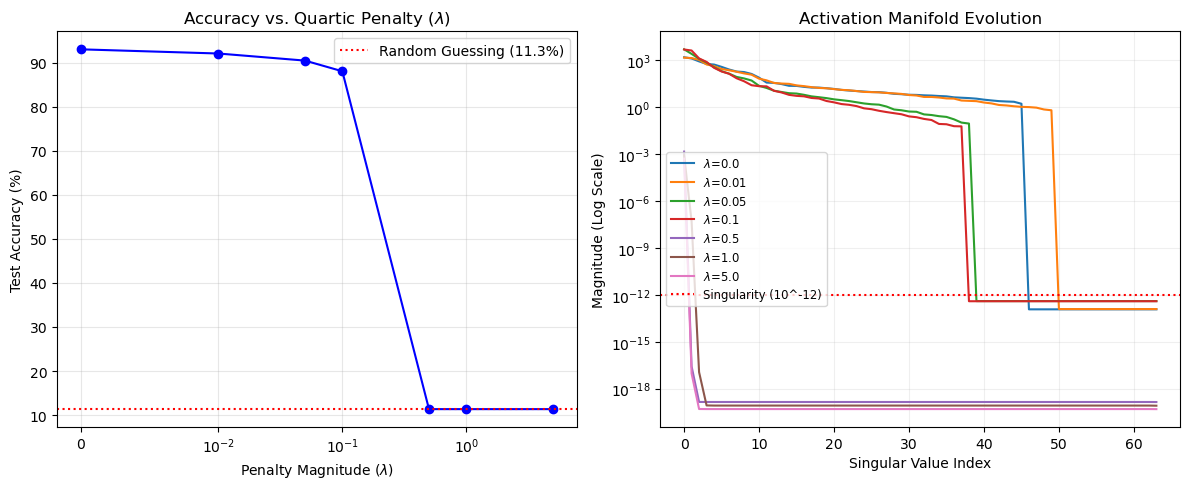

In [13]:

lambda_values = [0.0, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]
sweep_accuracies = []
sweep_singular_values = {}

print("--- Starting the Lambda Pressure Sweep ---")

for l in lambda_values:
    print(f"\nTraining Depth 10 Model with Lambda = {l}...")
    # Initialize a fresh model for each test
    model = DepthMLP(depth=10, width=64)
    
    # Train with the specific penalty (if l > 0)
    use_penalty = (l > 0)
    model = train_model(model, use_quartic_penalty=use_penalty, lambda_l4=l, epochs=5)
    
    # Evaluate
    acc, S = evaluate_and_extract(model)
    sweep_accuracies.append(acc)
    sweep_singular_values[l] = S
    print(f"Result: Accuracy = {acc:.2f}%")

# --- Plot 1: The Phase Transition (Accuracy vs Lambda) ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lambda_values, sweep_accuracies, marker='o', linestyle='-', color='b')
plt.xscale('symlog', linthresh=0.01) # Log scale for lambda to see the small values
plt.axhline(y=11.3, color='r', linestyle=':', label='Random Guessing (11.3%)')
plt.title('Accuracy vs. Quartic Penalty ($\lambda$)')
plt.xlabel('Penalty Magnitude ($\lambda$)')
plt.ylabel('Test Accuracy (%)')
plt.grid(True, alpha=0.3)
plt.legend()

# --- Plot 2: The Rank Collapse (Singular Values) ---
plt.subplot(1, 2, 2)
for l in lambda_values:
    plt.plot(sweep_singular_values[l], label=f'$\lambda$={l}')

plt.yscale('log')
plt.axhline(y=1e-12, color='r', linestyle=':', label='Singularity (10^-12)')
plt.title('Activation Manifold Evolution')
plt.xlabel('Singular Value Index')
plt.ylabel('Magnitude (Log Scale)')
plt.legend(fontsize='small')
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:32: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:32: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
/var/folders/n9/q2yfxjhx5t5f5dmwjjz0s6sh0000gn/T/ipykernel_66533/3343998075.py:31: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Critical Threshold: Accuracy vs. Quartic Penalty ($\lambda$)')
/var/folders/n9/q2yfxjhx5t5f5dmwjjz0s6sh0000gn/T/ipykernel_66533/3343998075.py:32: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Penalty Magnitude ($\lambda$)')
/var/folders/n9/q2yfxjhx5t5f5dmwjjz0s6sh0000gn/T/ipykernel_66533/3343998075.py:42: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(sweep_singular_values[l], label=f'$\lambda$={l}', linestyle=linestyle)


--- Finer Lambda Pressure Sweep ---

Training Depth 10 Model with Lambda = 0.1...
Result: Lambda = 0.1 | Accuracy = 88.02%

Training Depth 10 Model with Lambda = 0.12...
Result: Lambda = 0.12 | Accuracy = 86.74%

Training Depth 10 Model with Lambda = 0.13...
Result: Lambda = 0.13 | Accuracy = 87.87%

Training Depth 10 Model with Lambda = 0.14...
Result: Lambda = 0.14 | Accuracy = 87.65%

Training Depth 10 Model with Lambda = 0.15...
Result: Lambda = 0.15 | Accuracy = 87.13%

Training Depth 10 Model with Lambda = 0.16...
Result: Lambda = 0.16 | Accuracy = 86.40%

Training Depth 10 Model with Lambda = 0.17...
Result: Lambda = 0.17 | Accuracy = 11.35%

Training Depth 10 Model with Lambda = 0.18...
Result: Lambda = 0.18 | Accuracy = 11.35%

Training Depth 10 Model with Lambda = 0.19...
Result: Lambda = 0.19 | Accuracy = 11.35%

Training Depth 10 Model with Lambda = 0.2...
Result: Lambda = 0.2 | Accuracy = 11.35%


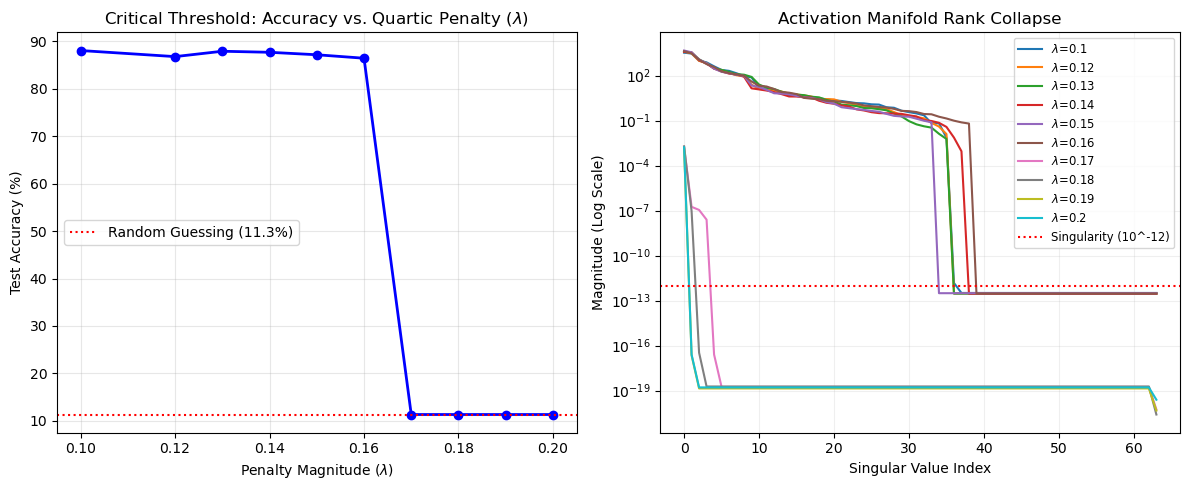

In [17]:

lambda_values = [0.1, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2]
sweep_accuracies = []
sweep_singular_values = {}

print("--- Finer Lambda Pressure Sweep ---")

for l in lambda_values:
    print(f"\nTraining Depth 10 Model with Lambda = {l}...")
    # Initialize a fresh model for each test to ensure no memory bleed
    # Setting seed for consistency
    torch.manual_seed(42)
    np.random.seed(42)
    
    model = DepthMLP(depth=10, width=64)
    
    # Train with the specific penalty
    model = train_model(model, use_quartic_penalty=True, lambda_l4=l, epochs=5)
    
    # Evaluate
    acc, S = evaluate_and_extract(model)
    sweep_accuracies.append(acc)
    sweep_singular_values[l] = S
    print(f"Result: Lambda = {l} | Accuracy = {acc:.2f}%")

# --- Plot 1: The Phase Transition (Accuracy vs Lambda) ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lambda_values, sweep_accuracies, marker='o', linestyle='-', color='b', linewidth=2)
plt.axhline(y=11.3, color='r', linestyle=':', label='Random Guessing (11.3%)')
plt.title('Critical Threshold: Accuracy vs. Quartic Penalty ($\lambda$)')
plt.xlabel('Penalty Magnitude ($\lambda$)')
plt.ylabel('Test Accuracy (%)')
plt.grid(True, alpha=0.3)
plt.legend()

# --- Plot 2: The Rank Collapse (Singular Values) ---
plt.subplot(1, 2, 2)
for l in lambda_values:
    # Use dashed lines for the collapsed models to make them stand out
    linestyle = '--' if l >= 0.8 else '-' # Guessing the transition is around 0.8
    plt.plot(sweep_singular_values[l], label=f'$\lambda$={l}', linestyle=linestyle)

plt.yscale('log')
plt.axhline(y=1e-12, color='r', linestyle=':', label='Singularity (10^-12)')
plt.title('Activation Manifold Rank Collapse')
plt.xlabel('Singular Value Index')
plt.ylabel('Magnitude (Log Scale)')
plt.legend(fontsize='small')
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()